In [1]:
from pop_gen import PopGen

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

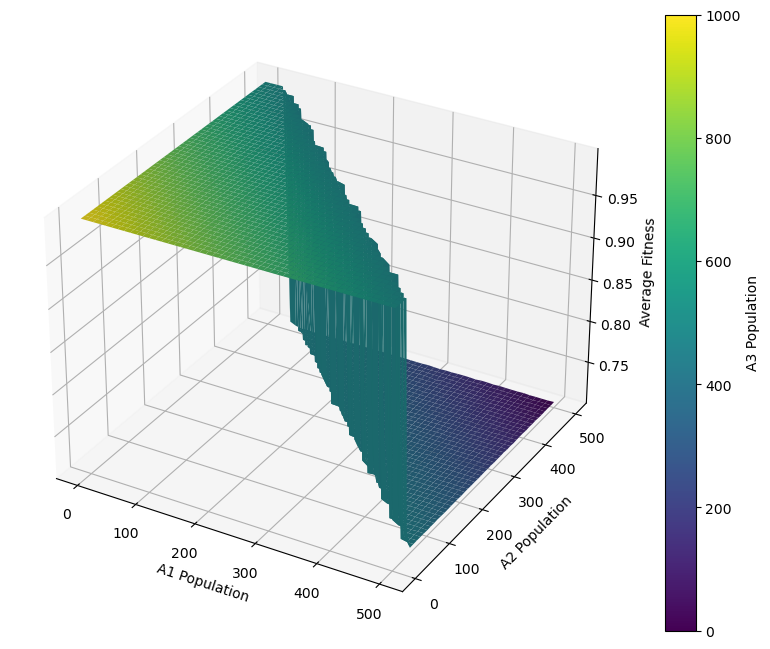

In [30]:
# Parameters
populations = 50
N = 1000

# Create arrays for A1, A2, and A3
A1_values = np.linspace(0, N / 2, populations)
A2_values = np.linspace(0, N / 2, populations)

# Prepare lists to store A1, A2, and A3 values
A1_list = []
A2_list = []
A3_list = []

# Calculate A1, A2, and A3 values
for i in range(populations):
    a1 = A1_values[i]
    for j in range(populations):
        a2 = A2_values[j] * (N - a1) / N 
        a3 = (N - a1 - a2)
        
        A1_list.append(a1)
        A2_list.append(a2)
        A3_list.append(a3)

# Convert lists to numpy arrays
A1_array = np.array(A1_list)
A2_array = np.array(A2_list)
A3_array = np.array(A3_list)

# Create an array to store average fitness values
average_fitnesses = np.zeros((populations, populations))

for i in range(populations):
    for j in range(populations):
        a1 = A1_values[i]
        a2 = A2_values[j]
        a3 = (N / 2) - a1 - a2

        # Simulation parameters 
        pg = PopGen()
        pg.genotype_data = {
            (('A1', 'A1'),) : {'Nm': a1 + a1, 'Nf': a1 + a1, 'Wm': 0.70, 'Wf': 0.70, 'covariance': 0},
            (('A1', 'A2'),) : {'Nm': a1 + a2, 'Nf': a1 + a2, 'Wm': 0.75, 'Wf': 0.75, 'covariance': 0},
            (('A1', 'A3'),) : {'Nm': a1 + a3, 'Nf': a1 + a3, 'Wm': 0.70, 'Wf': 0.70, 'covariance': 0},
            (('A2', 'A2'),) : {'Nm': a2 + a2, 'Nf': a2 + a2, 'Wm': 0.15, 'Wf': 0.15, 'covariance': 0},
            (('A2', 'A3'),) : {'Nm': a2 + a3, 'Nf': a2 + a3, 'Wm': 0.50, 'Wf': 0.50, 'covariance': 0},
            (('A3', 'A3'),) : {'Nm': a3 + a3, 'Nf': a3 + a3, 'Wm': 1.00, 'Wf': 1.00, 'covariance': 0},
        }
        pg.growth_rate = 0.1
        pg.carrying_capacity = 20000
        pg.max_drift = 0.1
        pg.mutation_rate = 0.01

        # Run the simulation
        pg.run(generations)

        # Store the average fitness
        average_fitnesses[i, j] = pg.get_last_average_fitness()

# Prepare data for 3D plotting
X, Y = np.meshgrid(A1_values, A2_values)
Z = average_fitnesses
A3_colors = (N - X - Y)  # A3 population for coloring

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
facecolors=plt.cm.viridis(A3_colors / np.max(A3_colors))

# Plot the surface with A3 as the color map
surface = ax.plot_surface(X, Y, Z, facecolors=facecolors, rstride=1, cstride=1, linewidth=0)

# Add color bar for the A3 population
m = plt.cm.ScalarMappable(cmap='viridis')
m.set_array(A3_colors)
fig.colorbar(m, ax=ax, label='A3 Population')

# Add labels and title
ax.set_xlabel('A1 Population')
ax.set_ylabel('A2 Population')
ax.set_zlabel('Average Fitness')

# Show the plot
plt.show()
